In [1]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   ../Cheatgrass_Pipeline_Runner.ipynb
	modified:   Cheatgrass_Pipeline_VEDU.ipynb
	modified:   ../cheatgrass_viz.py

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	../model_validmask_runs/training_curves_model_validmask_spatially_robust_20260127T101907-07cdcc3c.png

no changes added to commit (use "git add" and/or "git commit -a")


In [2]:
!nvidia-smi  # Check for GPUs
!lscpu       # Check CPU info

Failed to initialize NVML: Driver/library version mismatch
NVML library version: 570.211
Architecture:             x86_64
  CPU op-mode(s):         32-bit, 64-bit
  Address sizes:          48 bits physical, 48 bits virtual
  Byte Order:             Little Endian
CPU(s):                   32
  On-line CPU(s) list:    0-31
Vendor ID:                AuthenticAMD
  Model name:             AMD Ryzen Threadripper PRO 5955WX 16-Cores
    CPU family:           25
    Model:                8
    Thread(s) per core:   2
    Core(s) per socket:   16
    Socket(s):            1
    Stepping:             2
    Frequency boost:      enabled
    CPU max MHz:          4000.0000
    CPU min MHz:          1800.0000
    BogoMIPS:             7984.32
    Flags:                fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge m
                          ca cmov pat pse36 clflush mmx fxsr sse sse2 ht syscall
                           nx mmxext fxsr_opt pdpe1gb rdtscp lm constant_tsc rep
                

In [3]:
import geopandas as gpd
import pandas as pd

# Set pandas to display all columns without truncating them
pd.set_option('display.max_columns', None)

# The file path you provided
shapefile_path = '/home/rbielski/SAL_Git_Projects/Ventenata/Ventenata_Files/merge2324.shp'

print(f"Loading shapefile to display its header...")

try:
    # Load the shapefile
    gdf = gpd.read_file(shapefile_path)
    
    # Print the first 5 rows
    print("Shapefile loaded successfully. Here are the first 5 rows:")
    print(gdf.head())

except Exception as e:
    print(f"❌ An error occurred: {e}")

Loading shapefile to display its header...
Shapefile loaded successfully. Here are the first 5 rows:
   presence  Shape_Leng    Shape_Area observer_n   spp1          spp1_commo  \
0         1    0.000387  8.266529e-09       Ella   VEDU     Ventenata dubia   
1         1    0.000265  2.804779e-09      Simon  OTHER               OTHER   
2         1    0.000301  2.651498e-09      Simon   BRTE          Cheatgrass   
3         1    0.000493  1.059634e-08      Simon   PASM  Western wheatgrass   
4         1    0.000898  2.198568e-08      Simon   BRJA      Japanese Brome   

  spp1_statu  spp1_perce    spp1_pheno spp1_arran  spp2       spp2_commo  \
0          X        45.0         OTHER       None  VEDU  Ventenata dubia   
1         NA        45.0    Senescence       None  VEDU  Ventenata dubia   
2          X        30.0  Reproductive       None  VEDU  Ventenata dubia   
3          N        45.0     Seed Head    uniform  FORB            Sedge   
4          X        30.0  Panicle open    un


--- Loading and Validation for Plotting ---
✅ Columns successfully mapped.
✅ Percentage column validated.

--- Generating Data Distribution Plots ---


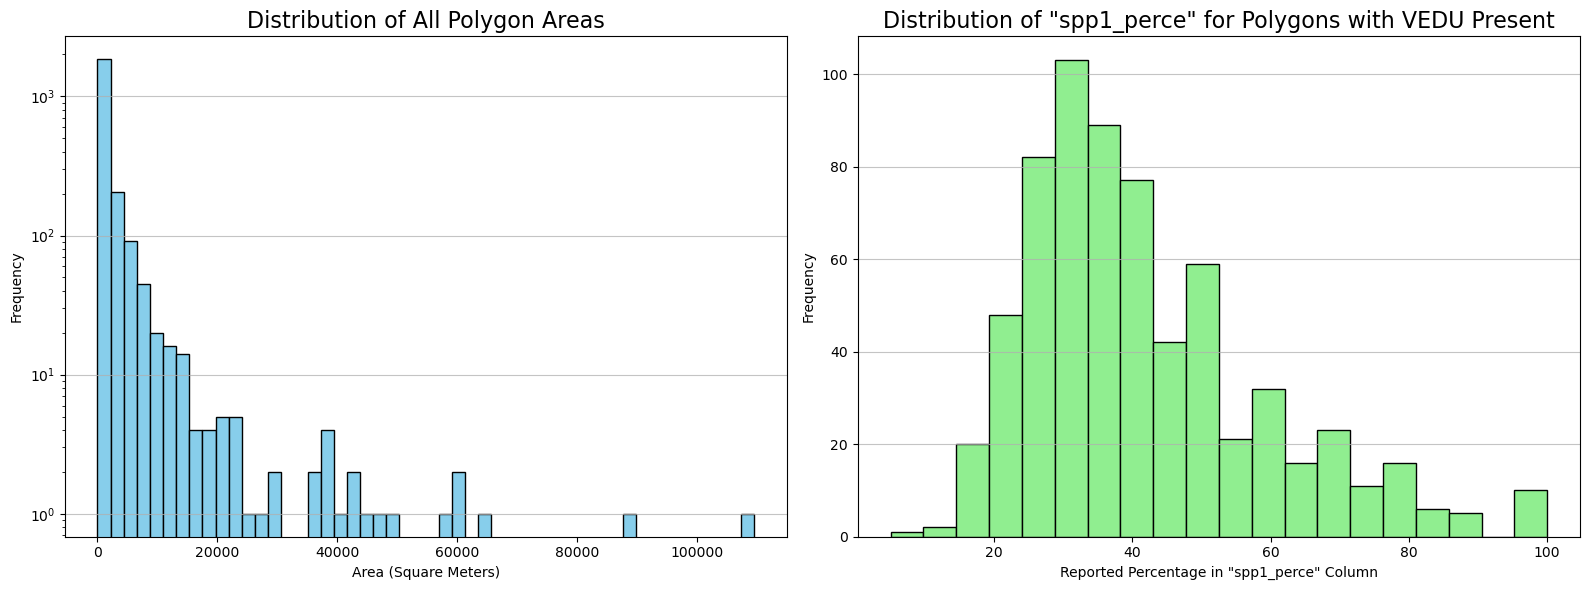

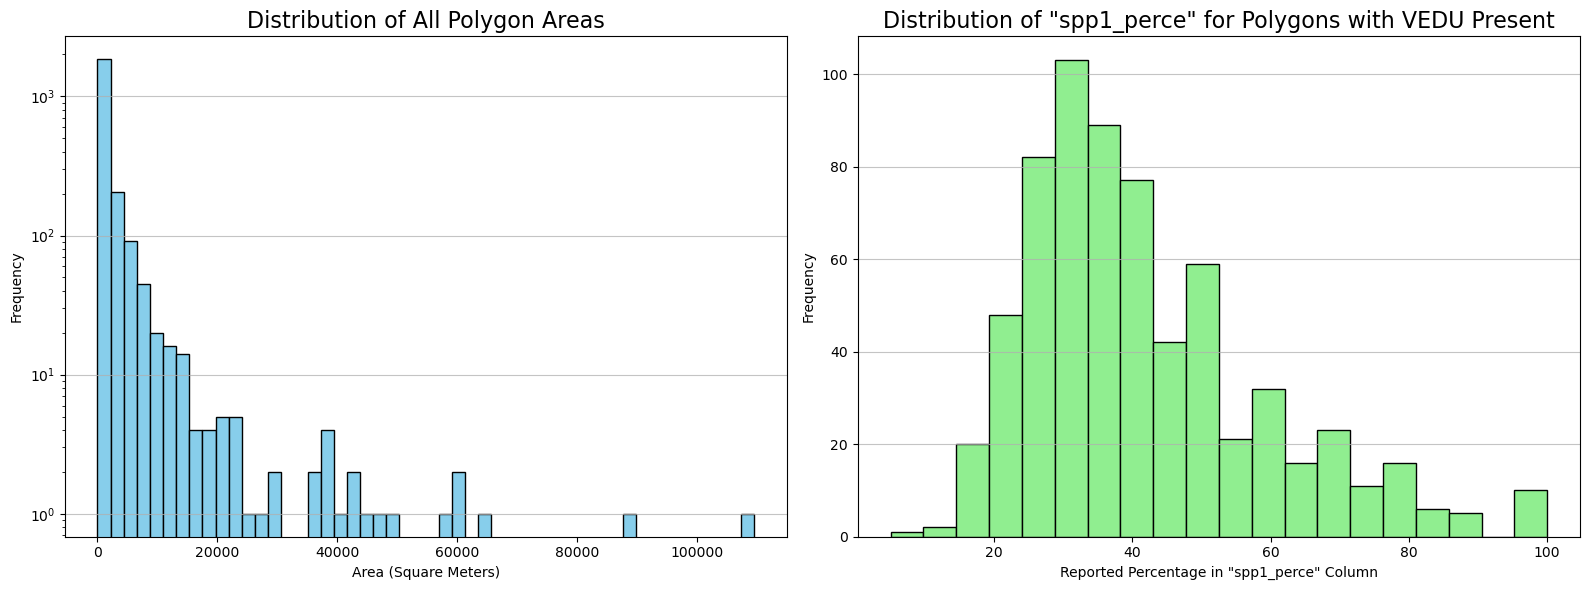

In [4]:
# --- BLOCK 1: EXPLORATORY DATA ANALYSIS (Corrected) ---
# Purpose: Load the raw data and visualize its distributions accurately.

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set pandas to display all columns without truncating them
pd.set_option('display.max_columns', None)


def load_and_validate_shapefile_for_plotting(filepath: str, column_map: dict) -> gpd.GeoDataFrame:
    """
    (Corrected for Plotting)
    Loads and prepares the shapefile, ensuring required columns exist and are numeric.
    """
    print(f"\n--- Loading and Validation for Plotting ---")
    gdf = gpd.read_file(filepath)
    
    # Check for required source columns before renaming
    source_cols = list(column_map.keys())
    missing = [col for col in source_cols if col not in gdf.columns]
    if missing:
        raise ValueError(f"Shapefile is missing expected columns: {missing}")

    # Rename the columns we will use
    gdf = gdf.rename(columns=column_map)
    print("✅ Columns successfully mapped.")
    
    # Ensure the main percentage column is numeric
    if not pd.api.types.is_numeric_dtype(gdf['primary_sp_percent']):
        gdf['primary_sp_percent'] = pd.to_numeric(gdf['primary_sp_percent'], errors='coerce').fillna(0)
    print("✅ Percentage column validated.")
    
    return gdf

def plot_data_distributions(gdf: gpd.GeoDataFrame, target_crs='EPSG:32611'):
    """
    (Corrected)
    Generates and returns a figure object with two histograms:
    1. Distribution of all polygon areas.
    2. True distribution of VEDU percentages, wherever VEDU is found.
    """
    print("\n--- Generating Data Distribution Plots ---")
    plot_gdf = gdf.copy()

    # --- 1. Area Histogram (No change needed here) ---
    plot_gdf['area_sqm'] = plot_gdf.to_crs(target_crs).geometry.area
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.hist(plot_gdf['area_sqm'], bins=50, color='skyblue', edgecolor='black')
    ax1.set_title('Distribution of All Polygon Areas', fontsize=16)
    ax1.set_xlabel('Area (Square Meters)')
    ax1.set_ylabel('Frequency')
    ax1.set_yscale('log')
    ax1.grid(axis='y', alpha=0.75)

    # --- 2. VEDU Percentage Histogram (New, more accurate logic) ---
    all_vedu_percentages = []
    
    # Unfortunately, the shapefile does not have separate percentage columns for spp2 and spp3.
    # The only percentage available is spp1_perce.
    # Therefore, we will plot the distribution of spp1_perce for all polygons where VEDU is present at all.
    vedu_present_gdf = plot_gdf[plot_gdf['is_vedu_present'] == 1]
    
    # We will use the 'primary_sp_percent' column for these rows.
    vedu_percentages = vedu_present_gdf['primary_sp_percent']

    ax2.hist(vedu_percentages, bins=20, color='lightgreen', edgecolor='black')
    ax2.set_title('Distribution of "spp1_perce" for Polygons with VEDU Present', fontsize=16)
    ax2.set_xlabel('Reported Percentage in "spp1_perce" Column')
    ax2.set_ylabel('Frequency')
    ax2.grid(axis='y', alpha=0.75)

    plt.tight_layout()
    return fig

# --- EXECUTION FOR PLOTTING ---

shapefile_path = '/home/rbielski/SAL_Git_Projects/Ventenata/Ventenata_Files/merge2324.shp'

# Based on your output, we create the correct map of column names.
# This map translates the file's column names to standard names our script can use.
column_name_map = {
    'presence': 'is_vedu_present',
    'spp1': 'primary_sp',
    'spp1_perce': 'primary_sp_percent',
    'spp2': 'spp2',
    'spp3': 'spp3',
    'global_id': 'global_id' 
}

# 1. Load the data using our corrected function and column map
initial_gdf = load_and_validate_shapefile_for_plotting(shapefile_path, column_name_map)

# 2. Generate the plot object
distribution_figure = plot_data_distributions(initial_gdf)

# 3. Display the plot directly in the notebook
distribution_figure

# LOAD SHAPEFILE FOR TRAINING


In [5]:
# =================================================================================
# --- DATA PROCESSING PIPELINE (Final Version with Corrected Control Filtering) ---
# =================================================================================

import pandas as pd
import geopandas as gpd
from sklearn.model_selection import train_test_split
import warnings

# Suppress specific warnings for a cleaner output
warnings.filterwarnings("ignore", message="The get_cmap function was deprecated", category=DeprecationWarning)
warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)

# --- HELPER FUNCTIONS (Unchanged) ---

def load_and_validate_shapefile(filepath: str, column_map: dict) -> gpd.GeoDataFrame:
    print(f"\n--- Loading and Validation ---")
    gdf = gpd.read_file(filepath)
    print(f"✅ Shapefile loaded successfully. Found {len(gdf)} rows and {len(gdf.columns)} columns.")
    
    source_cols = list(column_map.keys())
    missing = [col for col in source_cols if col not in gdf.columns]
    
    if missing:
        # Allow missing global_id - we'll generate it
        core_missing = [c for c in missing if c not in ['global_id', 'spp2', 'spp3']]
        if core_missing: 
            raise ValueError(f"Shapefile is missing critical columns: {core_missing}")
        else: 
            print(f"NOTE: Optional columns not found and will be ignored: {missing}")
    
    gdf = gdf.rename(columns=column_map)
    
    # Generate global_id if missing
    if 'global_id' not in gdf.columns:
        # Try to use existing ID column (OBJECTID, FID, etc.) or create from index
        for id_col in ['OBJECTID', 'objectid', 'ObjectID', 'FID', 'fid']:
            if id_col in gdf.columns:
                gdf['global_id'] = gdf[id_col].astype(str)
                print(f"✅ Generated global_id from {id_col}")
                break
        else:
            # No existing ID column, use index
            gdf['global_id'] = [f'vedu_{i:06d}' for i in range(len(gdf))]
            print("✅ Generated global_id from row index")
    
    print("✅ Columns successfully mapped.")
    for col in ['is_vedu_present', 'primary_sp_percent']:
        if not pd.api.types.is_numeric_dtype(gdf[col]):
            gdf[col] = pd.to_numeric(gdf[col], errors='coerce').fillna(0)
    print("✅ Key columns validated as numeric.")
    return gdf

def filter_vedu_polygons(gdf: gpd.GeoDataFrame, min_percent: float, min_area_sqm: float, target_crs='EPSG:32611') -> gpd.GeoDataFrame:
    # (This function is correct and remains the same)
    mask = (
        (gdf['is_vedu_present'] == 1) &
        ((gdf['primary_sp'] == 'VEDU') | (gdf.get('spp2') == 'VEDU') | (gdf.get('spp3') == 'VEDU')) &
        (gdf['primary_sp_percent'] > min_percent)
    )
    filtered_gdf = gdf[mask].copy()
    if filtered_gdf.empty: return filtered_gdf
    gdf_reprojected = filtered_gdf.to_crs(target_crs)
    gdf_reprojected['area_sqm'] = gdf_reprojected.geometry.area
    return gdf_reprojected[gdf_reprojected['area_sqm'] >= min_area_sqm].copy()

# --- MAIN DATA PREP FUNCTION (Final Corrected Version) ---
def generate_experimental_datasets_with_controls(
    filepath: str, column_map: dict, percent_thresholds: list, area_thresholds: list,
    target_crs='EPSG:32611', test_size=0.2, random_state=42
):
    base_gdf = load_and_validate_shapefile(filepath, column_map)
    
    master_train_gdf, final_test_set = train_test_split(
        base_gdf, test_size=test_size, stratify=base_gdf['is_vedu_present'], random_state=random_state
    )
    print("\n--- Master Sets Created ---")
    print(f"Master Training Set: {len(master_train_gdf)}")
    print(f"Final Held-Out Test Set: {len(final_test_set)}")

    print("\n--- Generating 25 Experimental Datasets ---")
    training_datasets = {}
    
    # Pre-calculate area for all training polygons once to be efficient
    master_train_gdf_reprojected = master_train_gdf.to_crs(target_crs)
    master_train_gdf_reprojected['area_sqm'] = master_train_gdf_reprojected.geometry.area

    for percent in percent_thresholds:
        for area in area_thresholds:
            experiment_name = f"percent_{percent}_area_{area}"
            print(f"\n>> Processing Experiment: {experiment_name}")
            
            # 1. Filter VEDU polygons from the master training set based on BOTH criteria
            vedu_mask = (
                (master_train_gdf_reprojected['is_vedu_present'] == 1) &
                ((master_train_gdf_reprojected['primary_sp'] == 'VEDU') | 
                 (master_train_gdf_reprojected.get('spp2') == 'VEDU') | 
                 (master_train_gdf_reprojected.get('spp3') == 'VEDU')) &
                (master_train_gdf_reprojected['primary_sp_percent'] > percent) &
                (master_train_gdf_reprojected['area_sqm'] >= area)
            )
            vedu_subset = master_train_gdf_reprojected[vedu_mask]
            
            # 2. Filter CONTROL polygons from the master training set based on AREA ONLY
            control_mask = (
                (master_train_gdf_reprojected['is_vedu_present'] == 0) &
                (master_train_gdf_reprojected['area_sqm'] >= area)
            )
            control_subset = master_train_gdf_reprojected[control_mask]

            print(f"  - Found {len(vedu_subset)} VEDU polygons and {len(control_subset)} Control polygons meeting criteria.")
            
            # 3. Combine the two correctly filtered subsets
            full_experiment_gdf = pd.concat([vedu_subset, control_subset], ignore_index=True)
            print(f"  - ✅ Total samples for this experiment: {len(full_experiment_gdf)}")
            
            training_datasets[experiment_name] = full_experiment_gdf
            
    print("\n\n✅✅✅ DATA PREPARATION PIPELINE COMPLETED SUCCESSFULLY ✅✅✅")
    return training_datasets, final_test_set

# ... (The rest of the script, including the EXECUTION block, can remain the same)


# =================================================================================
# --- CONFIGURATION AND EXECUTION ---
# =================================================================================
DEFAULT_PERCENT_VARIATIONS = [10, 25, 50, 66.6, 75]
DEFAULT_AREA_VARIATIONS = [100, 250, 500, 750, 900]
percent_variations = [10, 25, 50, 66.6, 75]
area_variations = [100, 250, 500, 750, 900]
shapefile_path = '/home/rbielski/SAL_Git_Projects/Ventenata/Ventenata_Files/merge2324.shp'
column_name_map = {
    'presence': 'is_vedu_present', 'spp1': 'primary_sp', 'spp1_perce': 'primary_sp_percent',
    'spp2': 'spp2', 'spp3': 'spp3', 'global_id': 'global_id' 
}

# Run the pipeline (moved to Step 2)
if False:
    experimental_sets, final_test_set = generate_experimental_datasets_with_controls(
        filepath=shapefile_path,
        column_map=column_name_map,
        percent_thresholds=percent_variations,
        area_thresholds=area_variations
    )

In [6]:
# =================================================================================
# --- STANDALONE VISUALIZATION: Detailed Categorical Plots & Maps ---
# =================================================================================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import contextily as cx

def create_all_final_plots(
    experimental_sets: dict,
    percent_thresholds: list,
    area_thresholds: list
):
    """
    Generates three final plots:
    1. A categorical heatmap showing the breakdown of VEDU vs. Control sites.
    2. A map showing all unique sites (VEDU colored, Controls gray).
    3. A map showing only the VEDU sites, colored by their most restrictive category.
    """
    print("\n--- Generating Final Comparison Plots ---")
    
    # --- Part 1: Create a consistent color map for all VEDU categories ---
    # The color will be based on the number of VEDU SITES ONLY to show a gradient of restrictiveness.
    vedu_counts = [len(gdf[gdf['is_vedu_present'] == 1]) for gdf in experimental_sets.values()]
    norm = plt.Normalize(vmin=min(vedu_counts), vmax=max(vedu_counts))
    # Using a reversed colormap so more restrictive categories (fewer polygons) are brighter
    colors = plt.cm.get_cmap('viridis_r', 25) 
    
    color_map = {}
    i = 0
    # We sort to ensure a consistent color progression in the map and heatmap
    for percent in sorted(percent_thresholds):
        for area in sorted(area_thresholds):
            name = f"percent_{percent}_area_{area}"
            vedu_count = len(experimental_sets[name][experimental_sets[name]['is_vedu_present'] == 1])
            color_map[name] = colors(norm(vedu_count))
            i += 1
    print("✅ Color map created for VEDU categories.")

    # --- Part 2: Create the Categorical Heatmap ---
    print("Generating detailed categorical heatmap...")
    heatmap_fig, ax1 = plt.subplots(figsize=(14, 9))
    ax1.set_title("Number of Polygons per Experiment (VEDU + Controls)", fontsize=16, pad=20)

    for i, percent in enumerate(sorted(percent_thresholds)):
        for j, area in enumerate(sorted(area_thresholds)):
            exp_name = f"percent_{percent}_area_{area}"
            exp_gdf = experimental_sets[exp_name]
            vedu_count = len(exp_gdf[exp_gdf['is_vedu_present'] == 1])
            control_count = len(exp_gdf[exp_gdf['is_vedu_present'] == 0])
            text_label = f"{vedu_count}\n({control_count})"
            
            ax1.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=color_map[exp_name]))
            text_color = "black" if norm(vedu_count) > 0.6 else "white"
            ax1.text(j + 0.5, i + 0.5, text_label, ha="center", va="center", color=text_color, fontsize=9, weight='bold')

    ax1.set_xlim(0, len(area_thresholds)); ax1.set_ylim(0, len(percent_thresholds))
    ax1.set_xticks(np.arange(len(area_thresholds)) + 0.5, labels=[f"{a} sqm" for a in sorted(area_thresholds)])
    ax1.set_yticks(np.arange(len(percent_thresholds)) + 0.5, labels=[f">{p}%" for p in sorted(percent_thresholds)])
    ax1.set_xlabel("Minimum Area Threshold", fontsize=12); ax1.set_ylabel("Minimum VEDU Percentage Threshold", fontsize=12)
    ax1.invert_yaxis()

    # --- Part 3: Prepare the data for mapping ---
    all_polygons_list = [gdf for gdf in experimental_sets.values() if not gdf.empty]
    if not all_polygons_list: return heatmap_fig, None, None
        
    master_gdf = pd.concat(all_polygons_list, ignore_index=True)
    unique_polygons_gdf = master_gdf.drop_duplicates(subset=['global_id']).copy()
    
    # Determine the single "best" (most restrictive) category for each polygon
    unique_polygons_gdf['best_category'] = 'control_site'
    for percent in sorted(percent_thresholds, reverse=True):
        for area in sorted(area_thresholds, reverse=True):
            exp_name = f"percent_{percent}_area_{area}"
            exp_gdf = experimental_sets[exp_name]
            unique_polygons_gdf.loc[unique_polygons_gdf['global_id'].isin(exp_gdf[exp_gdf['is_vedu_present']==1]['global_id']),'best_category'] = exp_name
    
    # Assign colors
    control_color = '#BDBDBD' # A neutral gray for controls
    unique_polygons_gdf['color'] = unique_polygons_gdf['best_category'].map(color_map).fillna(control_color)

    # --- Part 4: Create Map 1 (VEDU + Controls) ---
    print("Generating geospatial map with all sites...")
    points_all = unique_polygons_gdf.copy()
    points_all['geometry'] = points_all['geometry'].centroid
    points_all_web = points_all.to_crs(epsg=3857)
    
    map_fig_all, ax2 = plt.subplots(1, 1, figsize=(15, 12))
    points_all_web[points_all_web['best_category']=='control_site'].plot(ax=ax2, color=control_color, markersize=25, label='Control')
    points_all_web[points_all_web['best_category']!='control_site'].plot(ax=ax2, color=points_all_web['color'], markersize=50, edgecolor='black', linewidth=0.5)
    cx.add_basemap(ax2, source=cx.providers.OpenStreetMap.Mapnik)
    ax2.set_title("Geographic Distribution (VEDU Sites Colored by Category, Controls in Gray)", fontsize=16)
    ax2.set_axis_off()

    # --- Part 5: Create Map 2 (VEDU Only) ---
    print("Generating geospatial map with VEDU sites only...")
    points_vedu_only = unique_polygons_gdf[unique_polygons_gdf['is_vedu_present'] == 1].copy()
    if not points_vedu_only.empty:
        points_vedu_only['geometry'] = points_vedu_only['geometry'].centroid
        points_vedu_web = points_vedu_only.to_crs(epsg=3857)
        map_fig_vedu, ax3 = plt.subplots(1, 1, figsize=(15, 12))
        points_vedu_web.plot(ax=ax3, color=points_vedu_web['color'], markersize=50, edgecolor='black', linewidth=0.5)
        cx.add_basemap(ax3, source=cx.providers.OpenStreetMap.Mapnik)
        ax3.set_title("Geographic Distribution (VEDU Sites Only)", fontsize=16)
        ax3.set_axis_off()
    else:
        map_fig_vedu = None

    print("✅ All three figures created successfully.")
    return heatmap_fig, map_fig_all, map_fig_vedu

# --- EXECUTION ---
heatmap_figure, map_all_sites, map_vedu_only = create_all_final_plots(
    experimental_sets=experimental_sets,
    percent_thresholds=percent_variations,
    area_thresholds=area_variations
)

# --- DISPLAY PLOTS ---
print("\nDisplaying Detailed Categorical Heatmap (Legend):")
if heatmap_figure:
    display(heatmap_figure)

print("\nDisplaying Geospatial Map (VEDU Sites Colored, Controls in Gray):")
if map_all_sites:
    display(map_all_sites)
    
print("\nDisplaying Geospatial Map (VEDU Sites Only):")
if map_vedu_only:
    display(map_vedu_only)

NameError: name 'experimental_sets' is not defined

# only touch from here down

# VEDU pipeline runner (cheatgrass codebase)
Refreshed cells below use the ventenata polygons and the shared pipeline helpers.


In [ ]:
#Step 1

# Checks input polygons and relabel if needed

import os
from pathlib import Path
import geopandas as gpd

# Set your source polygons here
geo_path = Path('/home/rbielski/SAL_Git_Projects/Ventenata/Ventenata_Files/merge2324.shp')

# Load and optionally drop global_id for a clean copy
print('Loading:', geo_path)
gdf = gpd.read_file(geo_path)
has_global = 'global_id' in gdf.columns
print(f'Has global_id: {has_global}')
if has_global:
    print('Unique global_id:', gdf['global_id'].nunique())
    gdf_no_global = gdf.drop(columns=['global_id'])
    out_path = geo_path.with_stem(geo_path.stem + '_noglobal')
    gdf_no_global.to_file(out_path, driver='GeoJSON')
    print(f'Wrote copy without global_id: {out_path}')
else:
    gdf_no_global = gdf
    out_path = geo_path

print('Rows:', len(gdf_no_global))
for cand in ['objectid','OBJECTID','ObjectID','FID','fid']:
    if cand in gdf_no_global.columns:
        print(f"Unique {cand}: {gdf_no_global[cand].nunique()}")
        break

# Set input for downstream steps
os.environ['VEDU_INPUT_PATH'] = str(out_path)
print('VEDU_INPUT_PATH set to:', os.environ['VEDU_INPUT_PATH'])


Loading: /home/rbielski/SAL_Git_Projects/Ventenata/Ventenata_Files/merge2324.shp
Has global_id: True
Unique global_id: 1898
Wrote copy without global_id: /home/rbielski/SAL_Git_Projects/Ventenata/Ventenata_Files/merge2324_noglobal.shp
Rows: 2287
VEDU_INPUT_PATH set to: /home/rbielski/SAL_Git_Projects/Ventenata/Ventenata_Files/merge2324_noglobal.shp


In [ ]:

# Step 2
# generate experimental datasets/groups based on area and percent coverage using VEDU polygons

import os
from pathlib import Path
import geopandas as gpd
import pandas as pd

# Use functions defined earlier in the notebook
input_path = Path(os.environ.get('VEDU_INPUT_PATH', '/home/rbielski/SAL_Git_Projects/Ventenata/Ventenata_Files/merge2324.shp'))
percent_variations = DEFAULT_PERCENT_VARIATIONS
area_variations = DEFAULT_AREA_VARIATIONS

# Check if input file has global_id
temp_gdf = gpd.read_file(input_path)
has_global_id = 'global_id' in temp_gdf.columns

# Build column map based on what's available
column_name_map = {
    'presence': 'is_vedu_present',
    'spp1': 'primary_sp',
    'spp1_perce': 'primary_sp_percent',
    'spp2': 'spp2',
    'spp3': 'spp3',
}

# Only include global_id mapping if it exists in the file
if has_global_id:
    column_name_map['global_id'] = 'global_id'

# If no global_id, we'll generate one after loading
if not has_global_id:
    print("⚠️ No global_id column found - will generate one from available ID columns")

experimental_sets, final_test_set = generate_experimental_datasets_with_controls(
    filepath=str(input_path),
    column_map=column_name_map,
    percent_thresholds=percent_variations,
    area_thresholds=area_variations,
    target_crs='EPSG:32611',
    test_size=0.2,
    random_state=42,
)
print('Experiments generated:', list(experimental_sets.keys()))
print('Held-out test size:', len(final_test_set))

SyntaxError: invalid syntax (3034206019.py, line 1)

In [ ]:
# Step 3

# === Cheatgrass imagery ingestion (with inline Earthdata token) ===

# 0) Define token *here* and export it so hls_imagery_pipeline can see it
import os

# 1) Now import deps that rely on the token
import pandas as pd
import geopandas as gpd
from hls_imagery_pipeline import process_unique_polygon_list

print("
--- Preparing unique polygon list for VEDU imagery ingestion ---")

# 2) Collect all experiment GeoDataFrames
train_gdfs = [gdf for gdf in experimental_sets.values() if not gdf.empty]
if not train_gdfs:
    raise RuntimeError("No experimental sets available; did generate_experimental_datasets_with_controls() run successfully?")

# 3) Reproject final_test_set to match experiments (if needed)
try:
    exp_crs = train_gdfs[0].crs or "EPSG:32611"
    test_reproj = final_test_set.to_crs(exp_crs)
except Exception:
    test_reproj = final_test_set

# 4) Combine into a single master GDF
master = pd.concat(train_gdfs + [test_reproj], ignore_index=True)
if 'global_id' not in master.columns:
    master['global_id'] = [f'gid-{i:06d}' for i in range(len(master))]
master = master.drop_duplicates(subset=["global_id"]).copy()

# 5) Ensure presence column named is_cheatgrass for downstream code
if "is_cheatgrass" not in master.columns:
    if "is_vedu_present" in master.columns:
        master = master.rename(columns={"is_vedu_present": "is_cheatgrass"})
    else:
        master["is_cheatgrass"] = 1

print(f"Unique polygons: {len(master)} (positives: {int((master['is_cheatgrass']==1).sum())})")

# 6) Drop any invalid geometries
master = master[master.geometry.notna() & ~master.geometry.is_empty]
if master.empty:
    raise RuntimeError("No valid geometries to process for imagery ingestion.")

# 7) Run imagery pipeline; set cwd so outputs stay under VEDU directory
from pathlib import Path
vedu_root = Path('/home/rbielski/SAL_Git_Projects/Cheatgrass/VEDU_using_cheatgrass_pipeline')
os.chdir(vedu_root)
process_unique_polygon_list(master)


In [ ]:
# step 4

# Quality Metrics Analysis

from pathlib import Path
from quality_metrics_analysis import QualityConfig, run_quality_filter, TENSOR_DIR

# TENSOR_DIR is defined inside quality_metrics_analysis as Path("cheatgrass_data")

cfg = QualityConfig(
    tensor_dir=TENSOR_DIR,
    save_dir=Path("cheatgrass_quality_diagnostics"),

    # buffer radii in pixels
    buffer_radii_px=[3, 5],

    # (red_idx, nir_idx) in your band order; adjust if needed
    ndvi=(3, 4),

    # geometric filters (you can relax/tighten later)
    min_dates=5,
    min_interior_pixels=6,
    min_ring_pixels=1,
    min_ring_interior_ratio=0.01,

    # mask size / percent cover filters (optional; start permissive)
    min_mask_pixels=1,
    max_mask_pixels=None,
    min_percent_cover=None,
    max_percent_cover=None,

    # let thresholds & weights use the built-in defaults
    # thresholds={},  # leave empty → __post_init__ fills defaults
    # weights={},     # leave empty → uses default weighting

    # plotting + JSON export
    plots=True,
    export_json=True,
    verbose=False,
)

results_df_interactive, summary_df_interactive, filtered_experimental_sets = run_quality_filter(
    experimental_sets,
    cfg,
)

print("✅ Quality metrics analysis complete.")
print("   • Per-polygon/pair rows:", results_df_interactive.shape)
print("   • Per-polygon summary rows:", summary_df_interactive.shape)


In [ ]:
# step 5

# Filter after checking quality metrics

from create_quality_filtered_dataset import create_filtered_dataset

create_filtered_dataset()


In [ ]:
# step 6

# train test split

import importlib
from pathlib import Path
import train_test_split_from_quality as split_mod
split_mod = importlib.reload(split_mod)
SOURCE_DIR = Path('/home/rbielski/SAL_Git_Projects/Cheatgrass/VEDU_using_cheatgrass_pipeline')
DEST_ROOT  = Path('/home/rbielski/SAL_Git_Projects/Cheatgrass/VEDU_using_cheatgrass_pipeline')
TRAIN_RATIO = 0.8
SEED = 42
RESET_DEST = True

split_mod.run_split_from_quality(
    source_dir=SOURCE_DIR,
    dest_root=DEST_ROOT,
    train_ratio=TRAIN_RATIO,
    seed=SEED,
    reset_dest=RESET_DEST,
    build_validmask_copy=True,
)


In [ ]:
# step 7

# view tensors


from pathlib import Path
from tensor_viewer import launch_tensor_viewer, DEFAULT_DIR

# View final tensors (defaults to validmask copy if env set)
# Set CHEATGRASS_TENSOR_DIR to override, or pass a path below
launch_tensor_viewer(Path('/home/rbielski/SAL_Git_Projects/Cheatgrass/'))


In [ ]:
# step 8

# model training

# CUDA allocator tweak to reduce fragmentation
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

from datetime import datetime
print("Run started:", datetime.now().isoformat(timespec="seconds"))

from pathlib import Path
import numpy as np
import importlib
import cheatgrass_model as cm
cm = importlib.reload(cm)
ModelConfig = cm.ModelConfig
train = cm.train
discover_ids = cm.discover_ids

train_root = Path("/home/rbielski/SAL_Git_Projects/Cheatgrass/VEDU_using_cheatgrass_pipeline/cheatgrass_data_validmask_copy/train")
out_root   = Path("/home/rbielski/SAL_Git_Projects/Cheatgrass/VEDU_using_cheatgrass_pipeline/model_validmask_runs")

sample_files = sorted(train_root.glob("*_data.npy"))
if not sample_files:
    raise RuntimeError(f"No *_data.npy found in {train_root}")
example = np.load(sample_files[0])
T, H, W, C = example.shape
print(f"Detected data shape: T={T}, H={H}, W={W}, C={C}")

cfg = ModelConfig(
    data_dir=train_root,
    output_dir=out_root,
    batch_size=1,
    learning_rate=1e-4,
    epochs=50,
    hidden_dim=256,
    lstm_layers=2,
    lstm_dropout=0.1,
    attn_heads=16,
    input_bands=C,
    train_val_split_size=0.2,
    training_window_size=96,
    enable_augmentation=True,
    train_crops_per_sample=100,
    validation_crops_per_sample=100,
    train_negative_crop_prob=0.2,
    validation_negative_crop_prob=0.1,
    eval_negative_crop_prob=0.0,
    add_valid_channel=True,

    min_valid_fraction=0.05,

    verbose=True,
    use_checkpointing=True,
)

print("Skip guards are enabled inside cheatgrass_model: batches with non-finite data/valid masks are skipped.")

manifest = train(
    cfg,
    exp_name="validmask_spatially_robust",
    alpha=0.3,
    beta=0.7,
)
best_model_path = Path(manifest["best_model_path"])
best_threshold = manifest.get("best_threshold", 0.5)
print("Best threshold:", best_threshold)



In [ ]:
# step 9

# evaluate saved model
from datetime import datetime
print('Run started:', datetime.now().isoformat(timespec='seconds'))

import importlib, json
import numpy as np
from pathlib import Path
import cheatgrass_model as cm
cm = importlib.reload(cm)
ModelConfig = cm.ModelConfig
evaluate = cm.evaluate
discover_ids = cm.discover_ids

test_root = Path('/home/rbielski/SAL_Git_Projects/Cheatgrass/VEDU_using_cheatgrass_pipeline/cheatgrass_data_validmask_copy/test')
out_root  = Path('/home/rbielski/SAL_Git_Projects/Cheatgrass/VEDU_using_cheatgrass_pipeline/model_validmask_runs')

manifest_files = sorted(out_root.glob('run_*_manifest.json'))
if not manifest_files:
    raise RuntimeError(f'No run_*_manifest.json files found in {out_root}')
manifest_path = manifest_files[-1]
manifest = json.loads(manifest_path.read_text())
best_model_path = Path(manifest['best_model_path'])
best_threshold = manifest.get('best_threshold', 0.5)
print('Using manifest:', manifest_path.name)
print('Best model:', best_model_path)
print('Best threshold:', best_threshold)

sample_files = sorted(test_root.glob('*_data.npy'))
if not sample_files:
    raise RuntimeError(f'No *_data.npy found in {test_root}')
example = np.load(sample_files[0])
T, H, W, C = example.shape
print(f'Detected test data shape: T={T}, H={H}, W={W}, C={C}')

cfg_eval = ModelConfig(
    data_dir=test_root,
    output_dir=out_root,
    batch_size=1,
    learning_rate=1e-4,
    epochs=1,
    hidden_dim=512,
    lstm_layers=2,
    lstm_dropout=0.1,
    attn_heads=16,
    input_bands=C,
    train_val_split_size=0.2,
    training_window_size=96,
    enable_augmentation=False,
    train_crops_per_sample=1,
    validation_crops_per_sample=1,
    train_negative_crop_prob=0.0,
    validation_negative_crop_prob=0.0,
    eval_negative_crop_prob=0.0,
    use_checkpointing=True,
)

test_ids = discover_ids(test_root)
print(f'Found {len(test_ids)} test IDs')

results = evaluate(
    cfg_eval,
    model_path=best_model_path,
    test_ids=test_ids,
    threshold=best_threshold,
    crops_per_sample=20,
)


In [ ]:
# visualize eval + samples
from pathlib import Path
from cheatgrass_viz import visualize_eval_and_samples

visualize_eval_and_samples(
    cfg=cfg_eval,
    best_model_path=best_model_path,
    best_threshold=best_threshold,
    test_ids=test_ids,
    eval_results=results,
    max_examples=6,
)
